# Investigate Medical Appointment Dataset

### A person makes a doctor's appointment, receives all the instructions, and no-show. Who to blame?
In this notebook we will try to analyze why would some patient not show up for his medical appointment and whether there are reasons for that using the data we have.
We will try to find some correlation between the different attributes we have and whether the patient shows up or not. The dataset we are going to use contains 110.527 medical appointments and its 14 associated variables ( PatientId, AppointmentID, Gender, ScheduledDay, AppointmentDay, Age, Neighbourhood, Scholarship, Hypertension, Diabetes, Alcoholism, Handcap', SMS_received, No-show )

# Objectives

### Questions to answer

*   What is the percentage of no-show?
*   What factors are important for us to know in order to predict if a patient will show up for their scheduled appointment?
    *   Is the time gender related to whether a patient will show or not?
    *   Are patients with scholarship more likely to miss their appointment?
    *   Are patients who don't recieve sms more likely to miss their appointment?

In [3]:
#importing needed modules
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
#choose plots style
sns.set_style('darkgrid')
#make sure plots are inline with the notebook
%matplotlib inline


# Data Wrangling
# Loading the dataset and checking the columns we have

In [4]:
df = pd.read_csv("C:/Users/Maha Lakshmi/Downloads/archive/healthcare_noshows.csv")
df.head()

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,Showed_up,Date.diff
0,29872499824296,5642903,F,29-04-2016,29-04-2016,62,JARDIM DA PENHA,False,True,False,False,False,False,True,0
1,558997776694438,5642503,M,29-04-2016,29-04-2016,56,JARDIM DA PENHA,False,False,False,False,False,False,True,0
2,4262962299951,5642549,F,29-04-2016,29-04-2016,62,MATA DA PRAIA,False,False,False,False,False,False,True,0
3,867951213174,5642828,F,29-04-2016,29-04-2016,8,PONTAL DE CAMBURI,False,False,False,False,False,False,True,0
4,8841186448183,5642494,F,29-04-2016,29-04-2016,56,JARDIM DA PENHA,False,True,True,False,False,False,True,0


In [5]:
### Get the shape and types of our data
print(df.shape)
pd.DataFrame(df.dtypes)

(106987, 15)


,0
PatientId,int64
AppointmentID,int64
Gender,object
ScheduledDay,object
AppointmentDay,object
Age,int64
Neighbourhood,object
Scholarship,bool
Hipertension,bool
Diabetes,bool


In [6]:
### Get some statistics about our data
df.describe()

,PatientId,AppointmentID,Age,Date.diff
count,1.069870e+05,1.069870e+05,106987.000000,106987.000000
mean,1.472814e+14,5.675434e+06,38.316085,10.166721
std,2.558267e+14,7.133274e+04,22.466214,15.263508
min,3.921800e+04,5.030230e+06,1.000000,-6.000000
25%,4.173523e+12,5.640490e+06,19.000000,0.000000
50%,3.172463e+13,5.680744e+06,38.000000,4.000000
75%,9.433600e+13,5.725634e+06,56.000000,14.000000
max,9.999816e+14,5.790484e+06,115.000000,179.000000


In [7]:
### Check if there is any missing values in our data
df.info()
df.isna().any()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 106987 entries, 0 to 106986
Data columns (total 15 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   PatientId       106987 non-null  int64 
 1   AppointmentID   106987 non-null  int64 
 2   Gender          106987 non-null  object
 3   ScheduledDay    106987 non-null  object
 4   AppointmentDay  106987 non-null  object
 5   Age             106987 non-null  int64 
 6   Neighbourhood   106987 non-null  object
 7   Scholarship     106987 non-null  bool  
 8   Hipertension    106987 non-null  bool  
 9   Diabetes        106987 non-null  bool  
 10  Alcoholism      106987 non-null  bool  
 11  Handcap         106987 non-null  bool  
 12  SMS_received    106987 non-null  bool  
 13  Showed_up       106987 non-null  bool  
 14  Date.diff       106987 non-null  int64 
dtypes: bool(7), int64(4), object(4)
memory usage: 7.2+ MB


PatientId         False
AppointmentID     False
Gender            False
ScheduledDay      False
AppointmentDay    False
Age               False
Neighbourhood     False
Scholarship       False
Hipertension      False
Diabetes          False
Alcoholism        False
Handcap           False
SMS_received      False
Showed_up         False
Date.diff         False
dtype: bool

In [8]:
### Check if there is any duplicated rows in our data
df.duplicated().any()

False

<h3 style='color:blue'>Notes on data exploration</h3>

We can see from the info we got from our analysis that there are some columns that need to have their type corrected like dates.
Another great finding is that our data doesn't have any duplicated or missing values.
Also, the column no-show can be a bit confusing and we can invert the values to make it more intuitive (show instead of no-show) and we can also turn it to integer instead of yes or no.

### Data Cleaning

*   Drop irrelevant columns
*   Modify column names

In [10]:
### Drop irrelevant columns
df.drop(['PatientId','AppointmentID'],axis=1,inplace=True)
df.head()

,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,Showed_up,Date.diff
0,F,29-04-2016,29-04-2016,62,JARDIM DA PENHA,False,True,False,False,False,False,True,0
1,M,29-04-2016,29-04-2016,56,JARDIM DA PENHA,False,False,False,False,False,False,True,0
2,F,29-04-2016,29-04-2016,62,MATA DA PRAIA,False,False,False,False,False,False,True,0
3,F,29-04-2016,29-04-2016,8,PONTAL DE CAMBURI,False,False,False,False,False,False,True,0
4,F,29-04-2016,29-04-2016,56,JARDIM DA PENHA,False,True,True,False,False,False,True,0


In [11]:
### Change all cloumns name to lower case and replace all - with 
df.columns=df.columns.str.lower().str.replace('-','_')
pd.DataFrame(df.columns)

,0
0,gender
1,scheduledday
2,appointmentday
3,age
4,neighbourhood
5,scholarship
6,hipertension
7,diabetes
8,alcoholism
9,handcap


# Exploratory Data Analysis

In [31]:
#define function to get the ratio of show in different categories
def plot_rat(x):
    df.groupby(x).show.mean().plot(kind='bar',
                                    edgecolor='black',
                                    figsize=(14,8)).set_ylabel('Ratio of show');
    display(df.groupby(x)[['show']].mean())
#     plt.legend()

### What is the percentage of no-show?

In [32]:
#get some statistics about our data
df.describe()

,scheduledday,appointmentday,age,date.diff
count,106987,106987,106987.000000,106987.000000
mean,2016-05-08 21:18:53.330217728,2016-05-19 01:18:58.041070336,38.316085,10.166721
min,2015-11-10 00:00:00,2016-04-29 00:00:00,1.000000,-6.000000
25%,2016-04-29 00:00:00,2016-05-09 00:00:00,19.000000,0.000000
50%,2016-05-10 00:00:00,2016-05-18 00:00:00,38.000000,4.000000
75%,2016-05-20 00:00:00,2016-05-31 00:00:00,56.000000,14.000000
max,2016-06-08 00:00:00,2016-06-08 00:00:00,115.000000,179.000000
std,NaN,NaN,22.466214,15.263508


percentage of patients who didn't show up for their appointment is 20.26414424182378 %


,show
show,
False,21680
True,85307


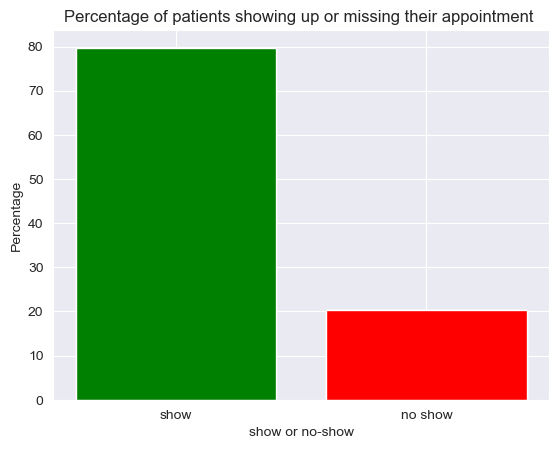

In [35]:
# percentage of show and no show
print(f"percentage of patients who didn't show up for their appointment is { (1-df.show.mean())*100 } %" )
no_show=len(df[df.show==0])/len(df.show)
show=len(df[df.show==1])/len(df.show)
plt.bar(['show','no show'],[show*100,no_show*100],color=['g','r']);
plt.title('Percentage of patients showing up or missing their appointment ');
plt.ylabel('Percentage');
plt.xlabel('show or no-show');
display(df.groupby('show')[['show']].count())
plt.show()

### What factors are important for us to know in order to predict if a patient will show up for their scheduled appointment?

In [56]:
#create filters for show and no-show
show=(df.show == True)
no_show=(df.show == False)
total_miss=len(df[no_show])
total=len(df)

### Is the time gender related to whether a patient will show or not?

percentage of Females and Males who missed their appointment:


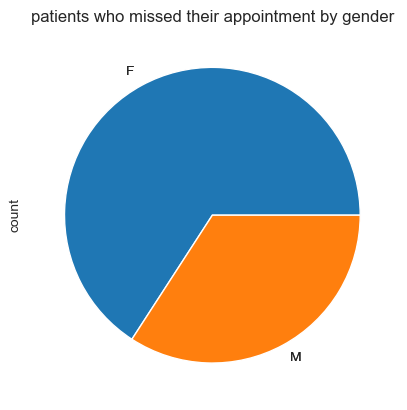

In [61]:
#get the number of patients missing their appointments by gender
no_show_gender=df[no_show]['gender'].value_counts()
no_show_gender.plot(kind='pie');
plt.title('patients who missed their appointment by gender');
print('percentage of Females and Males who missed their appointment:')
#get the percentage of patients missing their appointments by gender
pd.DataFrame(no_show_gender*100/total)
plt.show() 

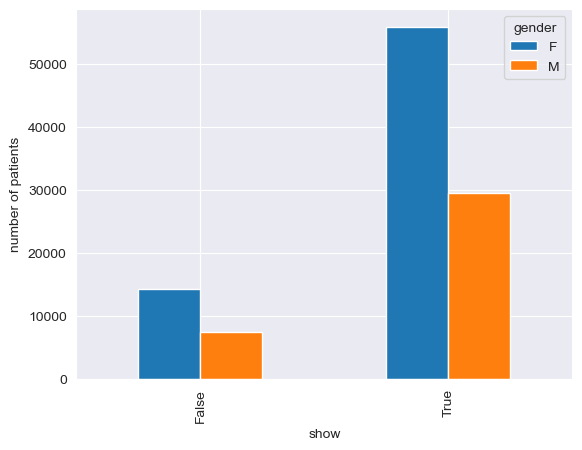

In [68]:
df.groupby(['gender','show']).size().unstack('gender').plot(kind='bar').set_ylabel('number of patients')
plt.show()

<h4 style='color:blue'>Finding</h4>

#### The percentage of females missing their appointment is nearly two times the number of males. So females are more likely to miss their appointment.

### Are patients with scholarships more likely to miss their appointment?

,show
scholarship,
False,0.801316
True,0.762143


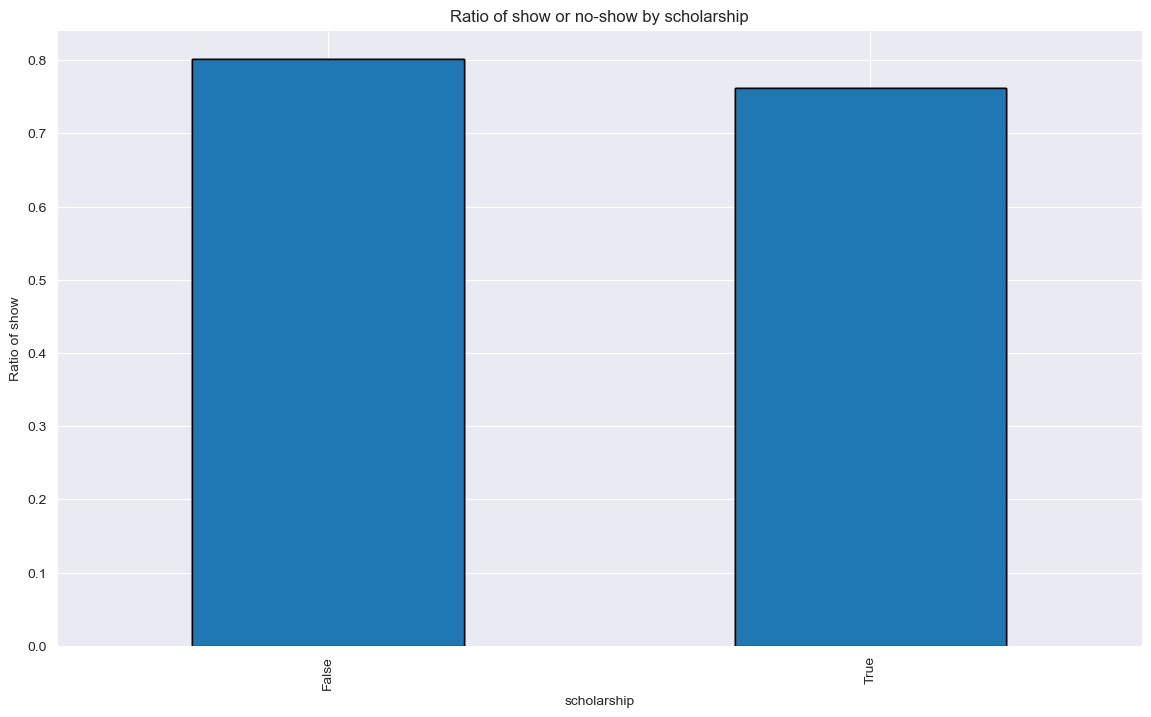

In [71]:
#what is the percentage of patients missing their appointment by scholarship
plot_rat(df.scholarship)
plt.title('Ratio of show or no-show by scholarship');
# df.groupby('scholarship')[['show']].mean()
plt.show()

<h4 style='color:blue'>Finding</h4>

#### It seems that patients with scholarships are actually more likely to miss their appointment

,show
hipertension,
False,0.789778
True,0.826980


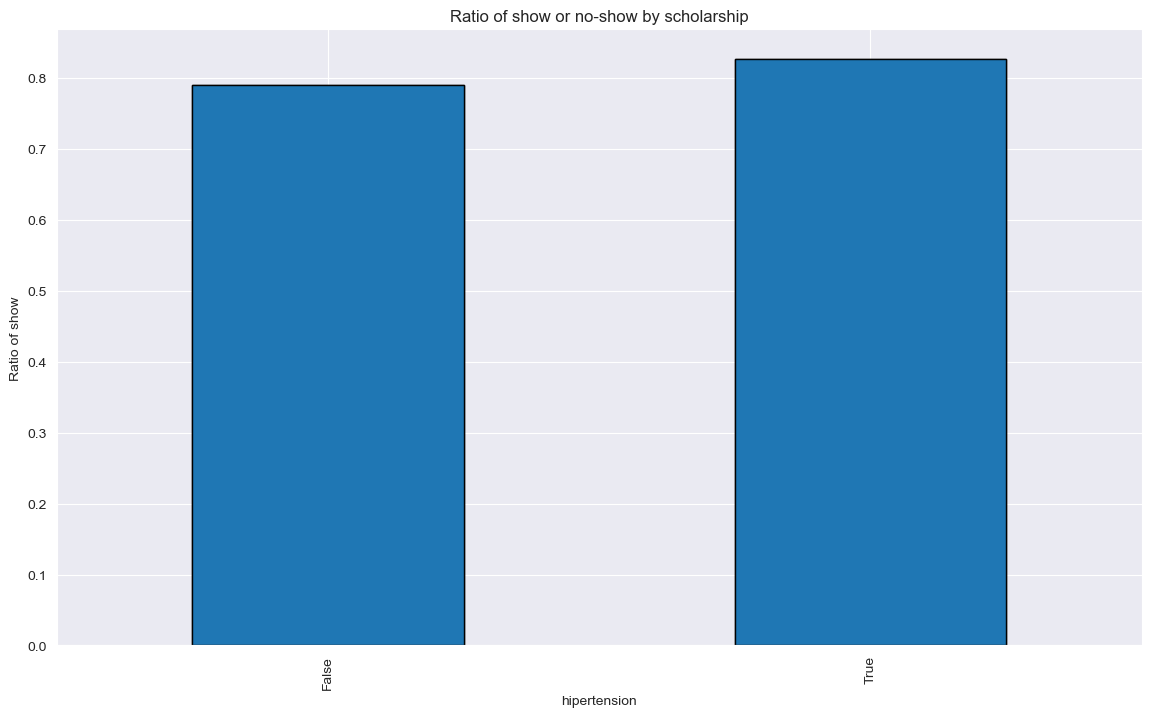

In [75]:
#what is the percentage of patients missing their appointment by hypertension
plot_rat(df.hipertension)
plt.title('Ratio of show or no-show by scholarship');
plt.show()

<h4 style='color:blue'>Finding</h4>

#### It seems that patients with hypertension are actually more likely to show up for their appointment

### Are patients who don't receive SMS more likely to miss their appointment?

,show
sms_received,
False,0.832712
True,0.723348


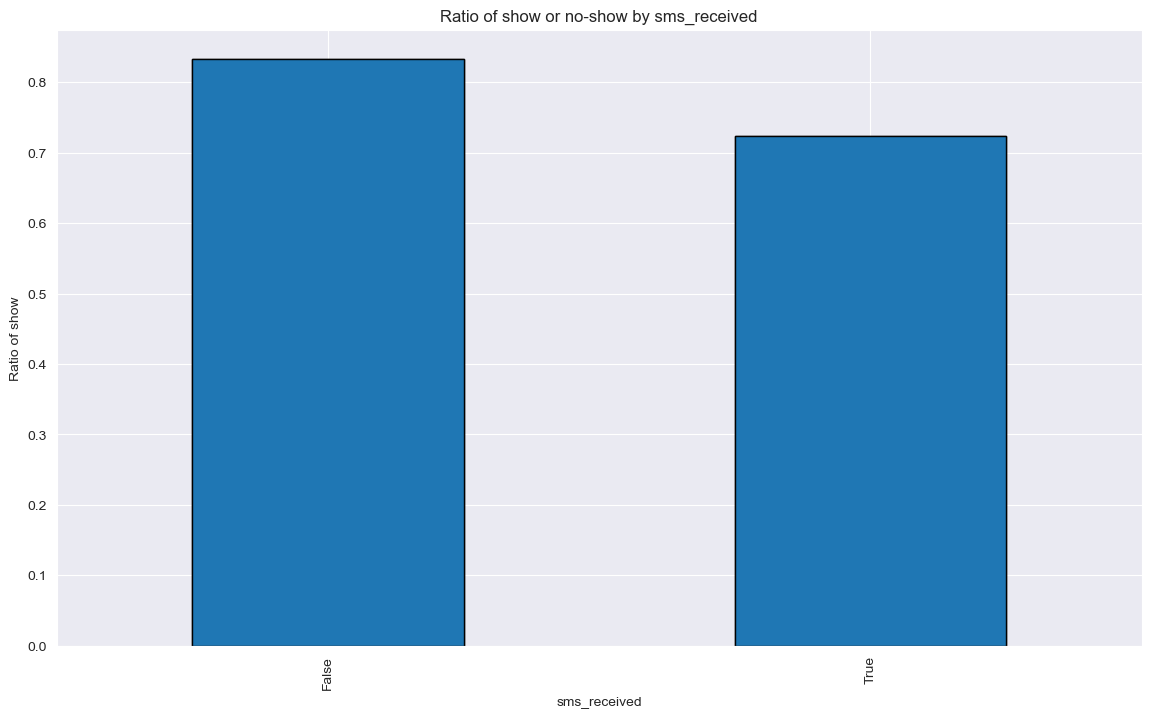

In [77]:
#what is the percentage of patient who attended their appointment by sms_received
plot_rat(df.sms_received)
plt.title('Ratio of show or no-show by sms_received');
plt.show()

<h4 style='color:blue'>Finding</h4>
It appears that the longer the period between the scheduling and appointment the more likely the patient won't show up.


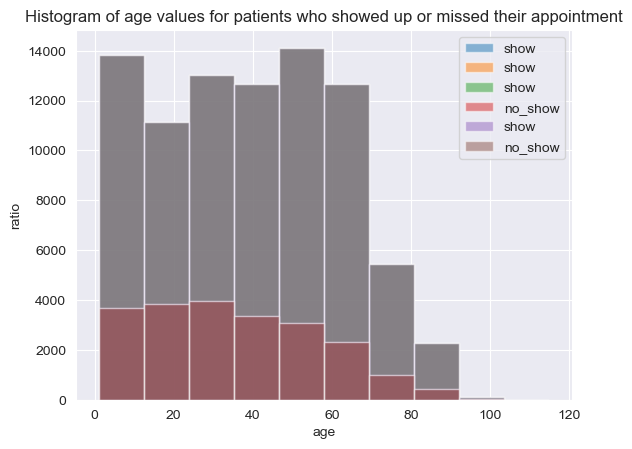

In [88]:
#plot the histograns of age for patients who showed up and who didn't
df[show].age.hist(alpha=0.5,label='show')
df[no_show].age.hist(alpha=0.5,label='no_show')
plt.legend()
plt.xlabel('age')
plt.ylabel('ratio')
plt.title('Histogram of age values for patients who showed up or missed their appointment')
#ger the mean age for patients who showed up and who didn't
df[no_show][['age']].describe()
plt.show()

# Conclusions

#### After analyzing the dataset here are some findings:
1. Percentage of patients who didn't show up for their appointment is 20.19%. 
2. The percentage of females missing their appointment is nearly two times the number of males. So females are more likely to miss their appointment.
3. It appears that the longer the period between the scheduling and appointment the more likely the patient won't show up.
4. It seems that patients with scholarships are actually more likely to miss their appointment.

 #### Analysis Shortcoming & Data Limitations
* The data doesn't state the exact hour of the appointment which would have been very useful to try to find out which hours have the most missing appointments and which doesn't. It could also be very useful to know the difference between scheduling and the appointment since many of the scheduling are on the same day.
* The data doesn't state if any day is a vacation or not which can indicate if people tend to miss their appointments more on working days.
* The age column had a negative value but according to the data creator, it means a baby not born yet (a pregnant woman).
* When calculating the day difference between the scheduling and appointment days we had some negative value which makes no sense and might mean that the records of questions have wrong data